# Exercise 3. Aperiodic Boundaries

3.1 Aperiodic Boundaries Introduce Edge Artifacts in the Grid Pattern

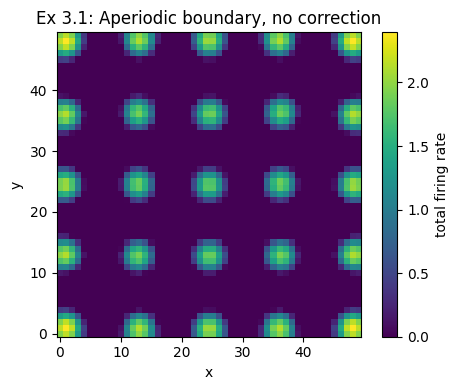

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from helper import Grid2DParams, AperiodicGridIntegrator

params3 = Grid2DParams(m=50)

velocity = np.zeros((400, 2))

net_aperiodic = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="none",
)

out_31 = net_aperiodic.simulate(
    velocity=velocity,
    seed=0,
    store_history=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(out_31["final_rate_total"], origin="lower", cmap="viridis")
plt.colorbar(label="total firing rate")
plt.title("Ex 3.1: Aperiodic boundary, no correction")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

With aperiodic boundaries, the network no longer forms a clean grid pattern over the whole sheet. The activity is strongly distorted by the edges, with high firing-rate bumps appearing near the boundaries and corners. This happens because neurons near the edge lose recurrent inputs from outside the sheet, so they do not experience the same effective connectivity as neurons in the center. Thus, removing the periodic wrapping breaks translational symmetry and introduces clear boundary artifacts.

3.2  2D radial masking envelope

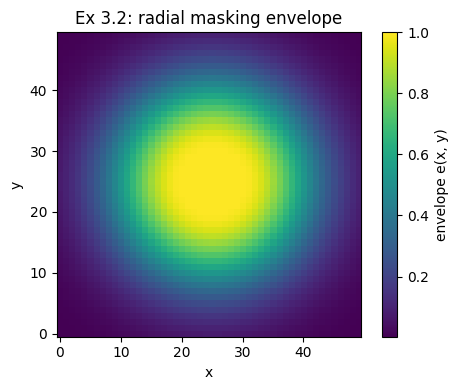

In [3]:
from helper import radial_envelope

env = radial_envelope(m=50, gamma=0.08, fratio=0.2)

plt.figure(figsize=(5, 4))
plt.imshow(env, origin="lower", cmap="viridis")
plt.colorbar(label="envelope e(x, y)")
plt.title("Ex 3.2: radial masking envelope")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

3.3 Boundary Firing-Rate Attenuation Partially Restores Central Bumps

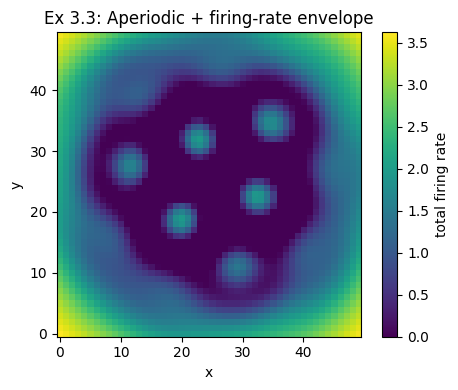

In [4]:
net_rate_env = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="rate_envelope",
)

out_33 = net_rate_env.simulate(
    velocity=velocity,
    seed=0,
    store_history=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(out_33["final_rate_total"], origin="lower", cmap="viridis")
plt.colorbar(label="total firing rate")
plt.title("Ex 3.3: Aperiodic + firing-rate envelope")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

For this simulation, I scaled the firing rates of the four populations by the radial envelope $e(\vec{x})$ before computing the recurrent convolution:

$$
r_N, r_S, r_E, r_W \rightarrow e(\vec{x}) r_N, e(\vec{x}) r_S, e(\vec{x}) r_E, e(\vec{x}) r_W.
$$

This implements the proposed attenuation of the outgoing weights of neurons near the boundary, because boundary neurons contribute less strongly to the recurrent input received by other neurons.

In the final activity pattern, several localized bumps are visible in the central region, so the network still maintains some grid-like structure. However, the correction is not perfect: in my simulation, strong activity remains near the edges and corners, and the pattern is less regular than in the periodic-boundary case. This suggests that attenuating outgoing recurrent influence reduces some boundary effects, but it does not fully remove the edge artifacts. One likely reason is that boundary neurons still receive the same external input, so their own activity can remain high even though their outgoing recurrent contribution is weakened.

3.4 Input Envelope Suppresses Boundary Artifacts More Effectively

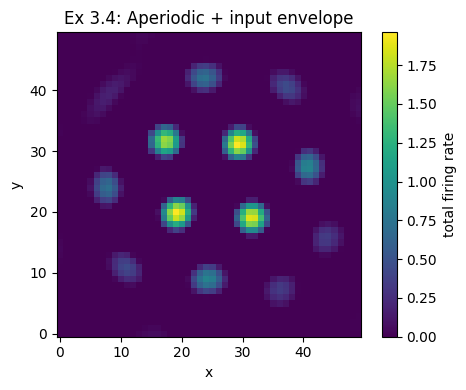

In [5]:
net_input_env = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="input_envelope",
)

out_34 = net_input_env.simulate(
    velocity=velocity,
    seed=0,
    store_history=True,
)

plt.figure(figsize=(5, 4))
plt.imshow(out_34["final_rate_total"], origin="lower", cmap="viridis")
plt.colorbar(label="total firing rate")
plt.title("Ex 3.4: Aperiodic + input envelope")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

For this simulation, I used the same aperiodic boundary condition as before, but instead of scaling the firing rates before convolution, I multiplied the external inputs by the radial envelope $e(\vec{x})$:

$$
B_N, B_S, B_E, B_W \rightarrow e(\vec{x})B_N, e(\vec{x})B_S, e(\vec{x})B_E, e(\vec{x})B_W.
$$

This makes the input position-dependent: neurons near the center receive the full input, while neurons near the boundary receive weaker input.

Compared with Ex. 3.3, the final activity pattern looks cleaner. The high-activity artifacts near the edges and corners are strongly reduced, and the activity is mainly concentrated in the central region. A grid-like bump pattern is still visible, although it is not perfectly regular because the aperiodic boundary and the spatial envelope break translational symmetry.

In my simulation, input attenuation works better than outgoing-weight attenuation. This suggests that directly reducing the drive to boundary neurons is more effective at suppressing boundary artifacts than only weakening their outgoing recurrent influence.

3.5 Comparing Boundary Corrections: Outgoing Weight Attenuation vs Input Attenuation

The two approaches differ in what is being attenuated near the boundary.

In Ex. 3.3, the envelope is applied to the firing rates before convolution:

$$
r_N, r_S, r_E, r_W \rightarrow e(\vec{x})r_N, e(\vec{x})r_S, e(\vec{x})r_E, e(\vec{x})r_S.
$$

This means that neurons near the boundary have weaker outgoing recurrent influence on the rest of the network. In other words, boundary neurons can still receive normal external input and become active, but their contribution to the recurrent input of other neurons is reduced.

In Ex. 3.4, the envelope is applied to the external inputs:

$$
B_N, B_S, B_E, B_W \rightarrow e(\vec{x})B_N, e(\vec{x})B_S, e(\vec{x})B_E, e(\vec{x})B_W.
$$

This means that neurons near the boundary receive weaker external drive in the first place. Therefore, boundary neurons are less strongly activated, which directly suppresses edge and corner artifacts.

In my simulations, the input-envelope approach in Ex. 3.4 works better. It produces a cleaner central grid-like pattern and reduces the strong boundary activity more effectively than the firing-rate envelope in Ex. 3.3. The firing-rate envelope still leaves noticeable edge artifacts, probably because boundary neurons continue to receive the same tonic input even though their outgoing recurrent effect is weakened.

This distinction has biological implications. The method in Ex. 3.3 corresponds more to a change in recurrent connectivity or synaptic output near the edge of the neural sheet. The method in Ex. 3.4 corresponds more to a spatial modulation of input drive, excitability, or gain. If a biological grid-cell circuit avoids boundary artifacts, the model suggests that regulating the spatial profile of neural input or excitability could be more effective than only modifying recurrent connections near the boundary.

3.6 Step-Wise Velocity Input Produces Approximate Grid Drift

In [6]:
from helper import stepwise_direction_velocity

params3 = Grid2DParams(m=50)

velocity, angles, segment_starts = stepwise_direction_velocity(
    warmup_steps=400,
    n_segments=12,
    segment_steps=150,
    speed=1.5,
    seed=2,
)

net_36 = AperiodicGridIntegrator(
    params=params3,
    boundary_mode="input_envelope",
)

out_36 = net_36.simulate(
    velocity=velocity,
    seed=0,
    store_history=True,
)

rate_total = out_36["rate_total"]

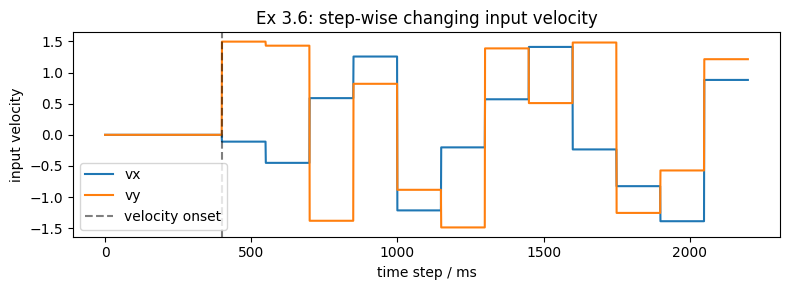

In [7]:
t = np.arange(len(velocity))

plt.figure(figsize=(8, 3))
plt.plot(t, velocity[:, 0], label="vx")
plt.plot(t, velocity[:, 1], label="vy")
plt.axvline(400, color="k", linestyle="--", alpha=0.5, label="velocity onset")
plt.xlabel("time step / ms")
plt.ylabel("input velocity")
plt.title("Ex 3.6: step-wise changing input velocity")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
from scipy.signal import correlate2d


def crop_center(img, crop_size=36):
    """
    Crop central region to reduce boundary effects.
    """
    m = img.shape[0]
    start = (m - crop_size) // 2
    end = start + crop_size
    return img[start:end, start:end]


def estimate_shift_by_correlation(img1, img2, max_shift=5, crop_size=36):
    """
    Estimate how much img2 is shifted relative to img1.

    Returns:
        dx, dy in neuron-index units.
    """
    a = crop_center(img1, crop_size=crop_size)
    b = crop_center(img2, crop_size=crop_size)

    # remove mean to focus on pattern structure
    a = a - a.mean()
    b = b - b.mean()

    corr = correlate2d(b, a, mode="same")

    cy, cx = np.array(corr.shape) // 2

    local = corr[
        cy - max_shift : cy + max_shift + 1,
        cx - max_shift : cx + max_shift + 1,
    ]

    peak_y, peak_x = np.unravel_index(np.argmax(local), local.shape)

    dy = peak_y - max_shift
    dx = peak_x - max_shift

    return dx, dy


def estimate_velocity_from_grid_drift(
    rate_total,
    segment_starts,
    segment_steps=150,
    lag=20,
    discard_steps=30,
    max_shift=5,
    crop_size=36,
):
    """
    Estimate one vx, vy per velocity segment.
    """
    estimates = []

    for start in segment_starts:
        shifts = []

        # avoid first few timesteps after velocity switch
        t0 = int(start + discard_steps)
        t1 = int(start + segment_steps - lag)

        for t in range(t0, t1, lag):
            dx, dy = estimate_shift_by_correlation(
                rate_total[t],
                rate_total[t + lag],
                max_shift=max_shift,
                crop_size=crop_size,
            )
            shifts.append([dx / lag, dy / lag])

        estimates.append(np.mean(shifts, axis=0))

    return np.array(estimates)

def estimate_velocity_from_grid_drift_segmentwise(
    rate_total,
    segment_starts,
    segment_steps=150,
    discard_steps=30,
    max_shift=12,
    crop_size=36,
):
    """
    Estimate one drift velocity per velocity segment using the shift between
    an early and a late activity map within the same segment.
    """
    estimates = []

    for start in segment_starts:
        t0 = int(start + discard_steps)
        t1 = int(start + segment_steps - 1)

        dx, dy = estimate_shift_by_correlation(
            rate_total[t0],
            rate_total[t1],
            max_shift=max_shift,
            crop_size=crop_size,
        )

        dt = t1 - t0
        estimates.append([dx / dt, dy / dt])

    return np.array(estimates)

In [16]:
estimated_v = estimate_velocity_from_grid_drift_segmentwise(
    rate_total,
    segment_starts,
    segment_steps=150,
    discard_steps=30,
    max_shift=12,
    crop_size=36,
)

true_v = velocity[segment_starts]

print("true velocity:")
print(true_v)

print("estimated velocity:")
print(estimated_v)

true velocity:
[[-0.10934471  1.49600927]
 [-0.44998023  1.43091502]
 [ 0.58901775 -1.37951371]
 [ 1.25672475  0.81892789]
 [-1.21296836 -0.88244419]
 [-0.20145172 -1.48641085]
 [ 0.57053104  1.38726145]
 [ 1.41085244  0.5094069 ]
 [-0.23436655  1.48157765]
 [-0.82406182 -1.25336432]
 [-1.38666298 -0.57198407]
 [ 0.88120307  1.21387032]]
estimated velocity:
[[-0.00840336  0.01680672]
 [-0.01680672  0.01680672]
 [ 0.         -0.03361345]
 [ 0.00840336  0.00840336]
 [-0.03361345 -0.02521008]
 [-0.00840336 -0.03361345]
 [ 0.          0.01680672]
 [ 0.01680672  0.        ]
 [-0.01680672  0.01680672]
 [-0.02521008 -0.02521008]
 [-0.03361345 -0.01680672]
 [ 0.00840336  0.01680672]]


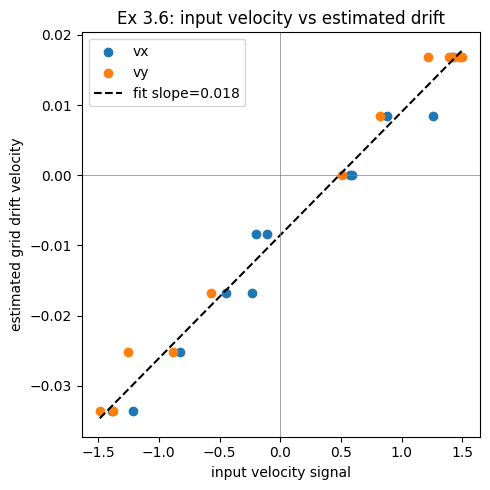

In [17]:
plt.figure(figsize=(5, 5))

plt.scatter(true_v[:, 0], estimated_v[:, 0], label="vx")
plt.scatter(true_v[:, 1], estimated_v[:, 1], label="vy")

x_all = np.concatenate([true_v[:, 0], true_v[:, 1]])
y_all = np.concatenate([estimated_v[:, 0], estimated_v[:, 1]])

slope, intercept = np.polyfit(x_all, y_all, deg=1)
x_line = np.linspace(x_all.min(), x_all.max(), 100)
plt.plot(x_line, slope * x_line + intercept, "k--", label=f"fit slope={slope:.3f}")

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)

plt.xlabel("input velocity signal")
plt.ylabel("estimated grid drift velocity")
plt.title("Ex 3.6: input velocity vs estimated drift")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Changlan Chen\AppData\Local\Temp\ipykernel_23452\3456842947.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


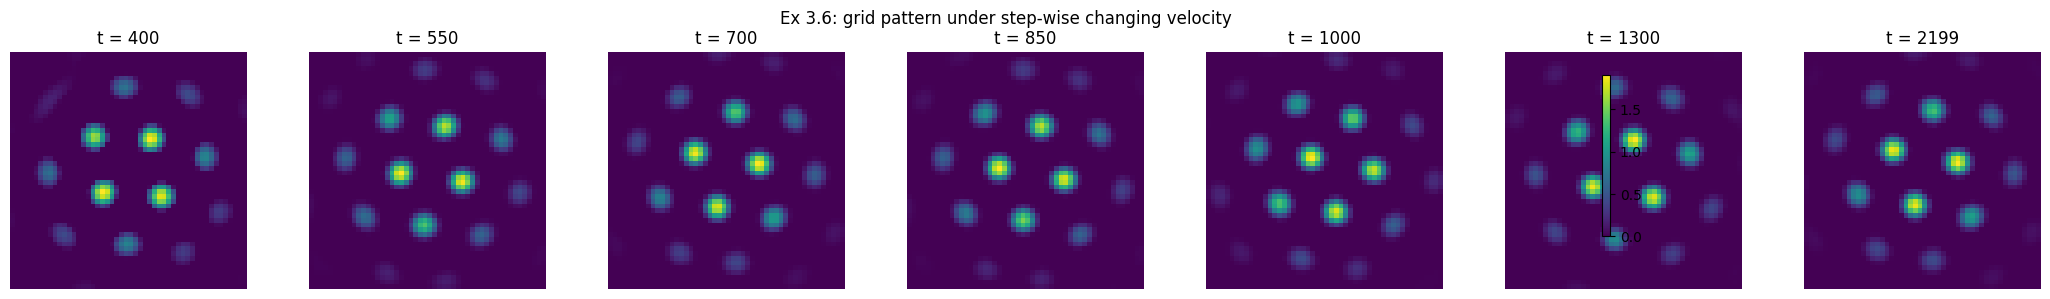

In [12]:
time_points = [400, 550, 700, 850, 1000, 1300, len(rate_total) - 1]

fig, axes = plt.subplots(1, len(time_points), figsize=(3 * len(time_points), 3))

for ax, tp in zip(axes, time_points):
    im = ax.imshow(rate_total[tp], origin="lower", cmap="viridis")
    ax.set_title(f"t = {tp}")
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.7)
plt.suptitle("Ex 3.6: grid pattern under step-wise changing velocity")
plt.tight_layout()
plt.show()

For this bonus simulation, I used the input-envelope aperiodic model from Ex. 3.4. I generated a velocity signal with fixed amplitude and step-wise changing direction. The velocity direction changed between segments after an initial zero-velocity warm-up period.

The grid-pattern snapshots show that the activity pattern drifts over time in response to the changing velocity input. However, the pattern does not move as a perfectly rigid lattice: the bump amplitudes and shapes also change slightly, especially because the aperiodic boundary and the input envelope break translational symmetry.

To estimate the drift velocity, I used cross-correlation between activity maps within each velocity segment to estimate the displacement of the grid pattern. The estimated drift velocity is approximately linearly related to the input velocity signal. The fitted slope is small because the input velocity is a dimensionless drive signal, whereas the estimated drift is measured as displacement on the neural sheet per timestep. Therefore, I do not expect a one-to-one relationship.

Overall, the network tracks the changing velocity direction qualitatively: the sign and relative magnitude of the estimated drift generally follow the input velocity. However, tracking is not perfect, and the grid pattern also changes in amplitude and shape rather than simply translating rigidly.